In [1]:
import os
os.chdir('../')

In [2]:
from config import GPTConfig
from tokenizer import BPETokenizer
from model.llm import LLM
import torch

In [3]:
tokenizer = BPETokenizer()
tokenizer.load("data/vocab.json", "data/merges.json")

In [4]:
torch.manual_seed(123)

model = LLM(GPTConfig())
model.eval()

LLM(
  (tok_emb): Embedding(8192, 768)
  (pos_emb): Embedding(512, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768

In [5]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [6]:
def text_to_token_idx(text, tokenizer):
    encoded = tokenizer.encode(text)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

In [7]:
sample_text = "Hello World"
text_to_token_idx(sample_text, tokenizer)

tensor([[  72, 3013,  539,  313,  336]])

In [8]:
def token_idx_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    text = tokenizer.decode(flat.tolist())
    return text

In [9]:
sample_text = "Hello World"
token_idx_to_text(text_to_token_idx(sample_text, tokenizer), tokenizer)

'Hello World'

In [10]:
start_context = "Every Effort Moves You"

token_ids = generate_text_simple(
 model=model,
 idx=text_to_token_idx(start_context, tokenizer),
 max_new_tokens=10,
 context_size=GPTConfig().context_length
)
print("Output text:\n", token_idx_to_text(token_ids, tokenizer))

Output text:
 Every Effort Moves You butterflies. j onion music.ish these flower. ruined.'m remain


In [11]:
file_path = r"D:\GptFromScratch\data\the_verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [12]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 6068


In [13]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [14]:
from data.dataset import create_dataloader

In [15]:
train_loader = create_dataloader(
 train_data,
 tokenizer,
 batch_size=2,
 max_length=GPTConfig.context_length,
 stride=GPTConfig.context_length,
 drop_last=True,
 shuffle=True,
 num_workers=0
)
val_loader = create_dataloader(
 val_data,
 tokenizer,
 batch_size=2,
 max_length=GPTConfig.context_length,
 stride=GPTConfig.context_length,
 drop_last=False,
 shuffle=False,
 num_workers=0
)

In [16]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
    
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 512]) torch.Size([2, 512])
torch.Size([2, 512]) torch.Size([2, 512])
torch.Size([2, 512]) torch.Size([2, 512])
torch.Size([2, 512]) torch.Size([2, 512])
torch.Size([2, 512]) torch.Size([2, 512])

Validation loader:
torch.Size([1, 512]) torch.Size([1, 512])


In [17]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
                                            logits.flatten(0, 1), target_batch.flatten()
                                            )
    return loss

In [18]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
            input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
    
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 9.18564338684082
Validation loss: 9.19198226928711


In [20]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
                                    train_loader, model, device, num_batches=eval_iter
                                    )
        val_loss = calc_loss_loader(
                                    val_loader, model, device, num_batches=eval_iter
                                    )
    model.train()
    
    return train_loss, val_loss

In [21]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_idx(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
        model=model, idx=encoded,
        max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_idx_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [ ]:
import math
import os
import wandb

def get_lr(step, warmup_steps, max_steps, max_lr, min_lr):
    if step < warmup_steps:
        return max_lr * (step / warmup_steps)
    if step > max_steps:
        return min_lr
    decay_ratio = (step - warmup_steps) / (max_steps - warmup_steps)
    coeff = 0.5 * (1 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)


def save_checkpoint(model, optimizer, epoch, global_step, train_losses, val_losses, path, wandb_run_id=None):
    torch.save({
        "epoch": epoch,
        "global_step": global_step,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "wandb_run_id": wandb_run_id,
    }, path)
    print(f"Checkpoint saved → {path}")


def load_checkpoint(path, model, optimizer, device):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    print(f"Resumed from {path} (epoch {checkpoint['epoch']+1}, step {checkpoint['global_step']})")
    return (
        checkpoint["epoch"],
        checkpoint["global_step"],
        checkpoint["train_losses"],
        checkpoint["val_losses"],
        checkpoint.get("wandb_run_id"),
    )

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, device,
                num_epochs, warmup_steps, max_steps, max_lr, min_lr,
                eval_freq, eval_iter, start_context, tokenizer,
                checkpoint_dir="checkpoints", checkpoint_freq=1,
                start_epoch=0, initial_step=0, wandb_run_id=None):

    os.makedirs(checkpoint_dir, exist_ok=True)
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, initial_step

    for epoch in range(start_epoch, num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:

            global_step += 1

            lr = get_lr(global_step, warmup_steps, max_steps, max_lr, min_lr)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f} | "
                      f"lr={lr:.2e}")
                wandb.log({
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "lr": lr,
                    "tokens_seen": tokens_seen,
                }, step=global_step)

        generate_and_print_sample(model, tokenizer, device, start_context)

        save_checkpoint(model, optimizer, epoch, global_step,
                        train_losses, val_losses,
                        os.path.join(checkpoint_dir, "latest.pt"),
                        wandb_run_id=wandb_run_id)

        if (epoch + 1) % checkpoint_freq == 0:
            save_checkpoint(model, optimizer, epoch, global_step,
                            train_losses, val_losses,
                            os.path.join(checkpoint_dir, f"ckpt_epoch{epoch+1}.pt"),
                            wandb_run_id=wandb_run_id)

    return train_losses, val_losses, track_tokens_seen

In [ ]:
max_lr = 4e-4
min_lr = max_lr * 0.1
warmup_steps = 20
num_epochs = 12

model = LLM(GPTConfig()).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=0.1)
max_steps = num_epochs * len(train_loader)

checkpoint_path = "checkpoints/latest.pt"

if os.path.exists(checkpoint_path):
    start_epoch, global_step, train_losses, val_losses, wandb_run_id = load_checkpoint(
        checkpoint_path, model, optimizer, device
    )
    start_epoch += 1
    wandb.init(
        project="gpt-from-scratch",
        id=wandb_run_id,
        resume="allow",
    )
else:
    torch.manual_seed(123)
    start_epoch, global_step = 0, 0
    train_losses, val_losses = [], []
    run = wandb.init(
        project="gpt-from-scratch",
        config={
            "d_model": GPTConfig.d_model,
            "n_layers": GPTConfig.n_layers,
            "n_heads": GPTConfig.n_heads,
            "vocab_size": GPTConfig.vocab_size,
            "context_length": GPTConfig.context_length,
            "max_lr": max_lr,
            "num_epochs": num_epochs,
        }
    )
    wandb_run_id = run.id
    print("Starting fresh training")

train_losses, val_losses, tokens_seen = train_model(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, max_lr=max_lr, min_lr=min_lr,
    warmup_steps=warmup_steps, max_steps=max_steps,
    eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer,
    start_epoch=start_epoch, initial_step=global_step,
    wandb_run_id=wandb_run_id,
)

wandb.finish()

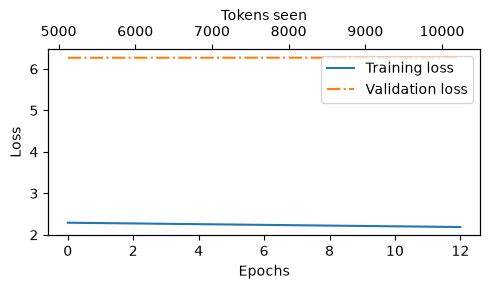

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
    epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
    
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)